# 📘 EDA and Sentiment Modeling
This notebook performs exploratory data analysis and builds sentiment classifiers.

In [11]:
!pip install -q textblob scikit-learn nltk seaborn transformers

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from nltk.probability import FreqDist
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from transformers import BertTokenizer

### 📂 Load the cleaned dataset

In [13]:
df = pd.read_csv("preprocessed_dafit_reviews.csv")

Loads the previously preprocessed review dataset from CSV.


### 🧠 Apply TextBlob for sentiment analysis

In [14]:
# Ensure content is in string format and missing values are handled
df['content_cleaned'] = df['content_cleaned'].fillna('').astype(str)

# Apply TextBlob sentiment analysis
df['sentiment_polarity'] = df['content_cleaned'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['sentiment_subjectivity'] = df['content_cleaned'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
df['sentiment_rating'] = df['score'].apply(lambda x: 'Positive' if x > 3 else ('Neutral' if x == 3 else 'Negative'))

Ensures text is cleaned, fills missing values, and applies TextBlob to compute sentiment polarity and subjectivity scores.

### 📊 Score distribution

<ipython-input-15-adda815fcf41>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='score', palette='Set2')


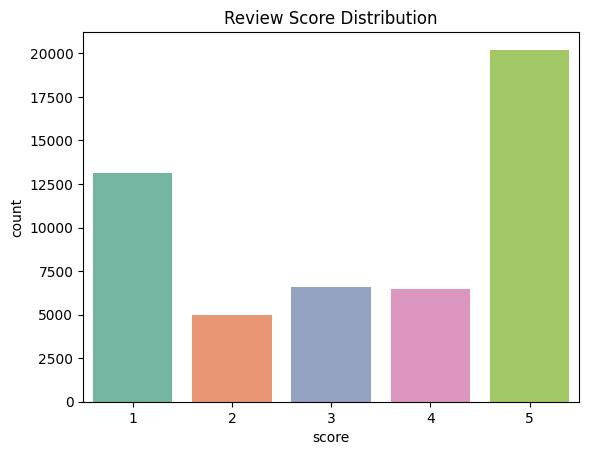

In [15]:
sns.countplot(data=df, x='score', palette='Set2')
plt.title('Review Score Distribution')
plt.show()

Plots how often each review score (1–5 stars) appears in the dataset.


### 📈 Polarity vs Subjectivity

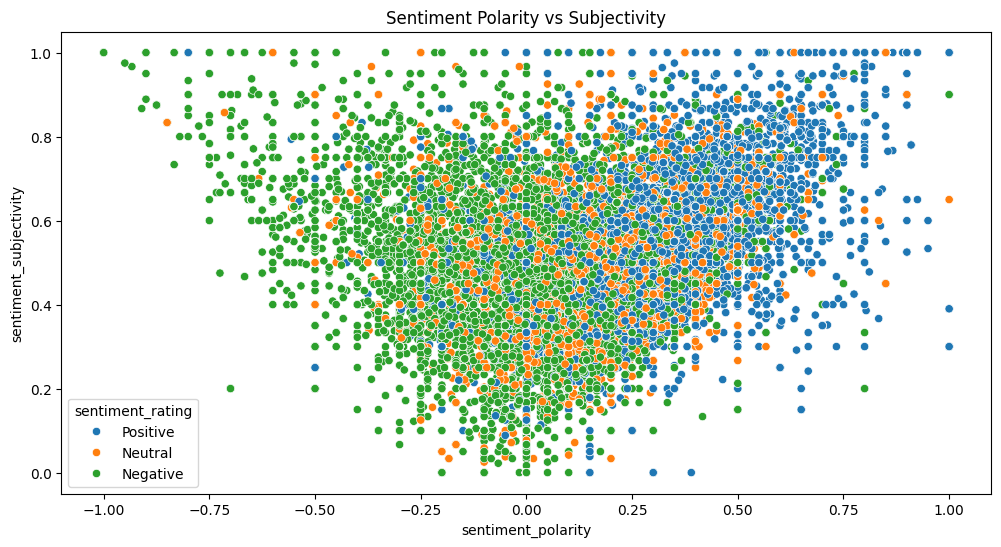

In [16]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='sentiment_polarity', y='sentiment_subjectivity', hue='sentiment_rating')
plt.title('Sentiment Polarity vs Subjectivity')
plt.show()

Scatter plot of sentiment polarity vs subjectivity for each review. Helps visualize sentiment spread.


### 🔤 Most frequent words

<ipython-input-17-0156f60a16d0>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=d, x='word', y='count', palette='rainbow')


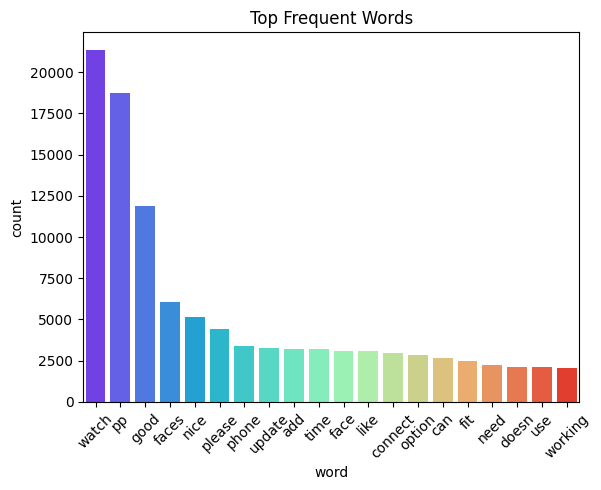

In [17]:
def freq_words(x, terms=20):
    all_words = ' '.join([text for text in x])
    all_words = all_words.split()
    fdist = FreqDist(all_words)
    df_freq = pd.DataFrame({'word': list(fdist.keys()), 'count': list(fdist.values())})
    d = df_freq.nlargest(columns='count', n=terms)
    sns.barplot(data=d, x='word', y='count', palette='rainbow')
    plt.xticks(rotation=45)
    plt.title('Top Frequent Words')
    plt.show()

freq_words(df['content_cleaned'])

Displays the top 20 most common words in cleaned reviews using a bar chart.


### 🧪 Train Sentiment Classifiers

In [18]:
df = df[df['sentiment_rating'] != 'Neutral']
df['label'] = df['sentiment_rating'].map({'Positive': 1, 'Negative': 0})

X_train, X_test, y_train, y_test = train_test_split(df['content_cleaned'], df['label'], test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
y_pred_nb = nb.predict(X_test_vec)
print("\nNaive Bayes Performance")
print(classification_report(y_test, y_pred_nb))

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, y_train)
y_pred_lr = lr.predict(X_test_vec)
print("\nLogistic Regression Performance")
print(classification_report(y_test, y_pred_lr))

<ipython-input-18-6e71bb7b1b3a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df['sentiment_rating'].map({'Positive': 1, 'Negative': 0})



Naive Bayes Performance
              precision    recall  f1-score   support

           0       0.80      0.86      0.83      3583
           1       0.90      0.86      0.88      5379

    accuracy                           0.86      8962
   macro avg       0.85      0.86      0.85      8962
weighted avg       0.86      0.86      0.86      8962


Logistic Regression Performance
              precision    recall  f1-score   support

           0       0.84      0.83      0.83      3583
           1       0.89      0.89      0.89      5379

    accuracy                           0.87      8962
   macro avg       0.86      0.86      0.86      8962
weighted avg       0.87      0.87      0.87      8962



Builds and evaluates two models (Naive Bayes & Logistic Regression) for classifying reviews as Positive or Negative.


### 🤖 BERT Tokenization Example

In [19]:
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
df['bert_tokens'] = df['content_cleaned'].apply(lambda x: bert_tokenizer.tokenize(x))
df[['content_cleaned', 'bert_tokens']].head()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

,content_cleaned,bert_tokens
0,good,[good]
2,watch huge pp useless,"[watch, huge, pp, useless]"
3,working scanning or code like what point scann...,"[working, scanning, or, code, like, what, poin..."
4,fantastic enjoy,"[fantastic, enjoy]"
8,pp useful nice,"[pp, useful, nice]"


Uses the BERT tokenizer to tokenize cleaned review text — useful if we want to train deep learning models later.
